In [1]:
from pathlib import Path

import json
import statistics
from collections import Counter

import matplotlib.pyplot as plt

In [2]:
BASE = Path("/workspace/tiny-llm-from-scratch")

DATASET = BASE / "datasets/processed/claude_mythos/clean_dataset.json"

REPORT_DIR = BASE / "datasets/reports"

REPORT_DIR.mkdir(parents=True, exist_ok=True)

print(DATASET)

/workspace/tiny-llm-from-scratch/datasets/processed/claude_mythos/clean_dataset.json


In [3]:
with open(DATASET, encoding="utf-8") as f:

    dataset = json.load(f)

print(len(dataset))

25000


In [4]:
prompt_lengths = []

response_lengths = []

prompt_words = []

response_words = []

categories = []

vocabulary = set()

In [5]:
for sample in dataset:

    user = sample["user"]

    assistant = sample["assistant"]

    categories.append(sample["category"])

    prompt_lengths.append(len(user))

    response_lengths.append(len(assistant))

    prompt_words.append(len(user.split()))

    response_words.append(len(assistant.split()))

    vocabulary.update(user)

    vocabulary.update(assistant)

In [6]:
stats = {

    "total_samples": len(dataset),

    "average_prompt_characters": round(statistics.mean(prompt_lengths),2),

    "average_response_characters": round(statistics.mean(response_lengths),2),

    "average_prompt_words": round(statistics.mean(prompt_words),2),

    "average_response_words": round(statistics.mean(response_words),2),

    "longest_prompt": max(prompt_lengths),

    "shortest_prompt": min(prompt_lengths),

    "longest_response": max(response_lengths),

    "shortest_response": min(response_lengths),

    "vocabulary_size": len(vocabulary)

}

stats

{'total_samples': 25000,
 'average_prompt_characters': 224.49,
 'average_response_characters': 1706.46,
 'average_prompt_words': 29.77,
 'average_response_words': 214.07,
 'longest_prompt': 268,
 'shortest_prompt': 179,
 'longest_response': 2119,
 'shortest_response': 1278,
 'vocabulary_size': 92}

In [7]:
category_counter = Counter(categories)

category_counter

Counter({'cybersecurity': 7000,
         'advanced_coding': 5500,
         'agentic_planning': 3500,
         'general_expert_qa': 3500,
         'mathematical_reasoning': 3000,
         'scientific_analysis': 2500})

In [8]:
category_file = REPORT_DIR / "category_distribution.json"

with open(category_file,"w",encoding="utf-8") as f:

    json.dump(

        dict(category_counter),

        f,

        indent=4,

        ensure_ascii=False

    )

print(category_file)

/workspace/tiny-llm-from-scratch/datasets/reports/category_distribution.json


In [9]:
stats_file = REPORT_DIR / "dataset_statistics.json"

with open(stats_file,"w",encoding="utf-8") as f:

    json.dump(

        stats,

        f,

        indent=4,

        ensure_ascii=False

    )

print(stats_file)

/workspace/tiny-llm-from-scratch/datasets/reports/dataset_statistics.json


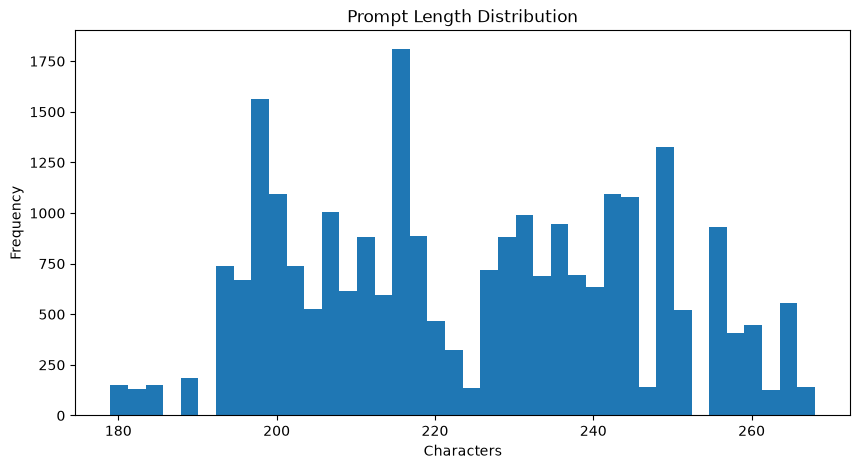

In [10]:
plt.figure(figsize=(10,5))

plt.hist(prompt_lengths, bins=40)

plt.title("Prompt Length Distribution")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

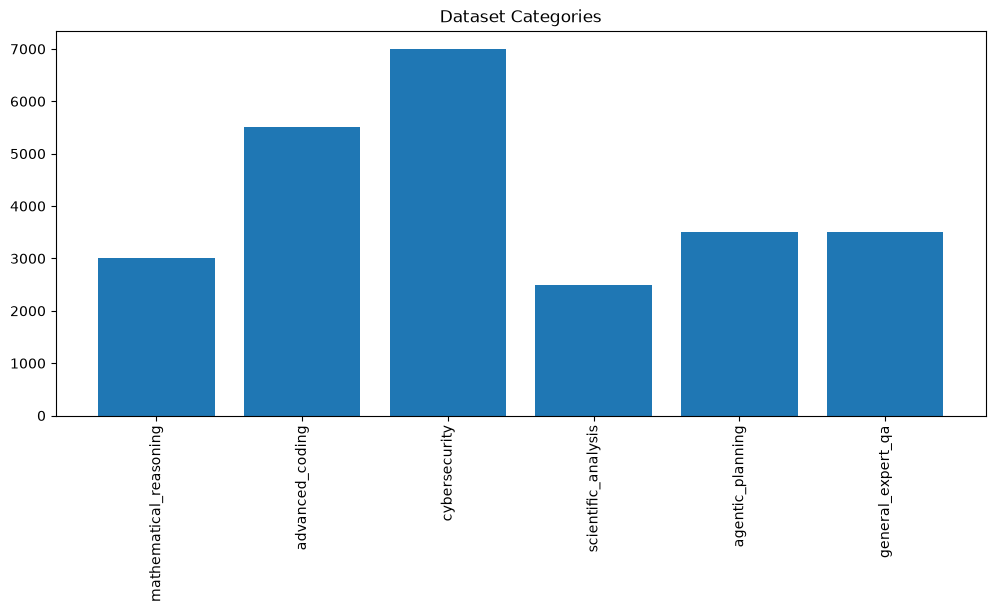

In [11]:
names = list(category_counter.keys())

counts = list(category_counter.values())

plt.figure(figsize=(12,5))

plt.bar(names, counts)

plt.xticks(rotation=90)

plt.title("Dataset Categories")

plt.show()

In [12]:
largest = max(dataset, key=lambda x: len(x["user"]))

print(largest["user"])

Conduct a full Mythos-style autonomous analysis of a hypothetical memory safety violation in C++ std::vector under concurrent access. Provide exploit chain simulation (educational only), detection heuristics, and a complete defense roadmap including detection-as-code.


In [13]:
print("="*70)

print("DATASET STATISTICS REPORT")

print("="*70)

for key, value in stats.items():

    print(f"{key:35} : {value}")

print()

print("Categories")

print("-"*70)

for k,v in category_counter.items():

    print(f"{k:35} : {v}")

print("="*70)

print("Dataset Statistics Completed Successfully")

print("="*70)

DATASET STATISTICS REPORT
total_samples                       : 25000
average_prompt_characters           : 224.49
average_response_characters         : 1706.46
average_prompt_words                : 29.77
average_response_words              : 214.07
longest_prompt                      : 268
shortest_prompt                     : 179
longest_response                    : 2119
shortest_response                   : 1278
vocabulary_size                     : 92

Categories
----------------------------------------------------------------------
mathematical_reasoning              : 3000
advanced_coding                     : 5500
cybersecurity                       : 7000
scientific_analysis                 : 2500
agentic_planning                    : 3500
general_expert_qa                   : 3500
Dataset Statistics Completed Successfully
